# 02 — Modelos e validação temporal corrigida

Este notebook apresenta os experimentos reproduzíveis dos scripts, sem repetir buscas caras. Execute antes: `ajustar_mlp.py`, `diagnostico_convergencia.py`, `comparar_regressao_logistica.py`, `avaliar_gradient_boosting.py` e `selecionar_finetuning.py`.

In [1]:
from pathlib import Path
import os
import sys
raiz = Path.cwd()
if not (raiz / 'analisar_dados_drift.py').exists():
    raiz = raiz.parent
assert (raiz / 'analisar_dados_drift.py').exists(), 'Abra o notebook dentro do repositorio.'
os.chdir(raiz)
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
import pandas as pd
import json
from IPython.display import display, Markdown, Image


## Validação sem sobreposição do horizonte

Para cada linha de treino em t, exigimos t+7 dias < início da validação. O scaler é ajustado apenas no treino. Os períodos de validação originais são preservados.

In [2]:
from ajustar_mlp import folds_temporais
d0 = pd.read_csv('dados/processados/base_d0.csv', parse_dates=['date'])
cortes = []
for i, (t, v, inicio) in enumerate(folds_temporais(d0.date, 4), 1):
    fim = d0.loc[t, 'date'].max()
    assert fim + pd.Timedelta(days=7) < inicio
    cortes.append(dict(fold=i, fim_treino=fim, inicio_validacao=inicio, n_treino=int(t.sum()), n_val=int(v.sum())))
display(pd.DataFrame(cortes))

,fold,fim_treino,inicio_validacao,n_treino,n_val
0,1,2014-08-13,2014-08-27,8500,8600
1,2,2016-04-06,2016-04-20,17100,8600
2,3,2017-11-29,2017-12-13,25700,8500
3,4,2019-07-17,2019-07-31,34200,8500


## Regressão logística do zero

Probabilidade: sigmoide de Xw+b. O treinamento minimiza entropia cruzada ponderada, com gradiente em lote e L2 opcional. A implementação usa logaddexp para estabilidade e verifica entradas e convergência. A comparação com a biblioteca usa a mesma função objetivo.

In [3]:
display(Markdown(Path('resultados/regressao_logistica/RELATORIO.md').read_text(encoding='utf-8')))

# E09-R1 — Regressao logistica com embargo

Reexecucao da grade original em D0, quatro folds expansivos com embargo de sete dias. Padronizacao ajustada somente no treino.

Configuracao: `{"nome": "lr_1_balanceado", "taxa_aprendizado": 1.0, "class_weight": "balanced", "l2": 0.0, "max_iter": 6000, "tolerancia": 1e-11, "criterio_selecao": "maior MCC medio arredondado a 4 casas; desempate por menor tempo medio; exige convergencia em todos os folds", "mcc_medio": 0.29493847216088753, "mcc_desvio": 0.05114322941164527}`.

MCC: 0.2949; desvio amostral entre folds: 0.0511.

Concordancia de classes com scikit-learn: 1.000000; correlacao de probabilidades: 0.99999990.

Decisao: usar esta configuracao na comparacao corrigida. Resultados antigos preservados em resultados/historico_sem_embargo/. D1 e D2 nao utilizados.


## MLP: convergência e generalização

O teto revisado é uma margem computacional; a parada depende da perda de treino. Convergência não garante melhor generalização. O diagnóstico abrange os quatro folds e três sementes.

In [4]:
display(Markdown(Path('resultados/convergencia/RELATORIO.md').read_text(encoding='utf-8')))
display(pd.read_csv('resultados/convergencia/diagnostico.csv'))

# E06-R1 — Diagnostico de convergencia

Mesma configuracao escolhida em D0, com embargo, quatro folds e tres seeds.

- Teto 100: 7/12 ajustes convergiram; MCC medio 0.3143; MCC treino 0.4259; maximo observado 100 epocas.
- Teto 800: 12/12 ajustes convergiram; MCC medio 0.3134; MCC treino 0.4281; maximo observado 171 epocas.

A diferenca treino/validacao deve ser interpretada como sinal potencial de sobreajuste. Aumentar o teto permite estabilizar a perda; nao implica melhorar MCC. Nenhuma decisao usa D1 ou D2.


,fold,seed,teto,epocas,convergiu,tempo_s,mcc_treino,mcc,f1,precision,recall,accuracy,roc_auc,pr_auc
0,1,42,100,100,False,1.004616,0.459893,0.409438,0.637131,0.647870,0.626742,0.720000,0.768709,0.645054
1,1,42,800,144,True,3.628079,0.467030,0.415243,0.643315,0.646882,0.639787,0.721744,0.766909,0.641892
2,1,1337,100,86,True,2.350808,0.454471,0.403326,0.634344,0.642445,0.626445,0.716744,0.766015,0.639392
3,1,1337,800,86,True,2.128283,0.454471,0.403326,0.634344,0.642445,0.626445,0.716744,0.766015,0.639392
4,1,2024,100,100,False,2.480996,0.463545,0.395915,0.629730,0.637968,0.621702,0.713256,0.765938,0.634910
5,1,2024,800,171,True,4.669018,0.461713,0.378354,0.615174,0.632717,0.598577,0.706279,0.762074,0.626676
6,2,42,100,100,False,5.078402,0.455100,0.349205,0.581392,0.584918,0.577907,0.701279,0.740588,0.580873
7,2,42,800,107,True,6.323428,0.454471,0.343723,0.577944,0.581258,0.574668,0.698721,0.739885,0.582302
8,2,1337,100,81,True,5.113168,0.436470,0.326711,0.552826,0.588515,0.521218,0.697326,0.734284,0.579675
9,2,1337,800,81,True,5.025034,0.436470,0.326711,0.552826,0.588515,0.521218,0.697326,0.734284,0.579675


## Comparação das três famílias

Configurações selecionadas exclusivamente em D0. Os resultados são de validação usada na seleção, não de teste independente. Variação entre folds e entre sementes são reportadas separadamente.

In [5]:
display(Markdown(Path('resultados/gradient_boosting/RELATORIO.md').read_text(encoding='utf-8')))

# E10 — Gradient Boosting em D0

Hipotese: arvores impulsionadas capturam relacoes nao lineares e podem superar
MLP e regressao logistica nos mesmos quatro folds temporais de D0.

Busca: 16 configuracoes x quatro folds, seed 42, maior MCC medio.
Escolha: GB01, `{"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 15, "l2_regularization": 0.0, "class_weight": "balanced"}`.
Early stopping desativado; sem padronizacao para arvores. Pesos balanceados
sao calculados pelo estimador somente no treino de cada fold.

| Familia | MCC medio ± desvio temporal | F1 | PR-AUC (AP) | Treino s/fold |
|---|---:|---:|---:|---:|
| Gradient Boosting | 0.3542 ± 0.0541 | 0.5989 | 0.5774 | 1.117 |
| MLP | 0.3134 ± 0.0604 | 0.5345 | 0.5614 | 6.847 |
| Logistica do zero | 0.2949 ± 0.0443 | 0.5660 | 0.5331 | 3.499 |

MLP e Gradient Boosting usam seeds 42, 1337 e 2024; logistica deterministica
usa uma execucao. As configuracoes anteriores da MLP e logistica foram
reavaliadas neste ambiente, sem nova busca. Tempo inclui padronizacao quando
aplicavel. Desvio temporal: ddof=0 sobre medias por fold entre seeds;
variabilidade entre seeds esta registrada separadamente no CSV.

Interpretacao: a tabela compara validacao usada na selecao, nao desempenho
futuro independente. O vencedor de Gradient Boosting fica selecionado para
baseline; a MLP permanece modelo principal dos experimentos de atualizacao.
MCC de treino e validacao por fold permitem examinar sobreajuste.
Maior MCC nesta comparacao: Gradient Boosting.
MLP atingiu o limite de epocas em 0 de 12 ajustes.
O CSV registra iteracoes: atingir o limite de 800 na MLP exige cautela
quanto a convergencia, sem alterar sua configuracao durante esta comparacao.

Correcao R1: embargo de sete dias em todos os folds. Nenhum alvo de treino
alcanca a validacao. Os periodos de validacao foram preservados e a semana
imediatamente anterior foi retirada do treino. As tres selecoes foram refeitas.
Resultados anteriores estao em resultados/historico_sem_embargo/.

D1 e D2 nao foram carregados. Artefatos: busca_folds.csv, comparacao_folds.csv,
comparacao_familias.csv, configuracao_escolhida.json e protocolo.json.
O protocolo registra data, hash, grade, ambiente, sementes e tempo total.


## Atualização por fine-tuning em D1

D1a atualiza os pesos de M0; D1b escolhe a configuração/épocas, com embargo de uma semana. O scaler continua sendo o de D0. Três hipóteses: taxa 10× menor, taxa original, e taxa menor com L2 forte. D2 não é acessado.

{'config': 'B_lr_original',
 'learning_rate_init': 0.003,
 'alpha': 0.01,
 'epocas': 1,
 'mcc_d1b': 0.212,
 'ganho_vs_m0_d1b': 0.0218,
 'fracao_d1a': 0.75,
 'seeds': [42, 1337, 2024],
 'hiperparametros_m0': {'hidden_layer_sizes': [32],
  'alpha': 0.01,
  'learning_rate_init': 0.003,
  'max_iter': 800,
  'mcc_validacao_d0': 0.32127737803036627,
  'mcc_desvio_d0': 0.06488396493474491,
  'folds': 4,
  'seed_busca': 42,
  'embargo_dias': 7,
  'convergiu_por_fold': [True, True, True, True],
  'iteracoes_por_fold': [144, 107, 72, 84]},
 'embargo_d1_dias': 7,
 'configuracoes_testadas': {'A_lr_baixo': {'learning_rate_init': 0.00030000000000000003,
   'alpha': 0.01},
  'B_lr_original': {'learning_rate_init': 0.003, 'alpha': 0.01},
  'C_lr_baixo_reg_forte': {'learning_rate_init': 0.00030000000000000003,
   'alpha': 1.0}}}

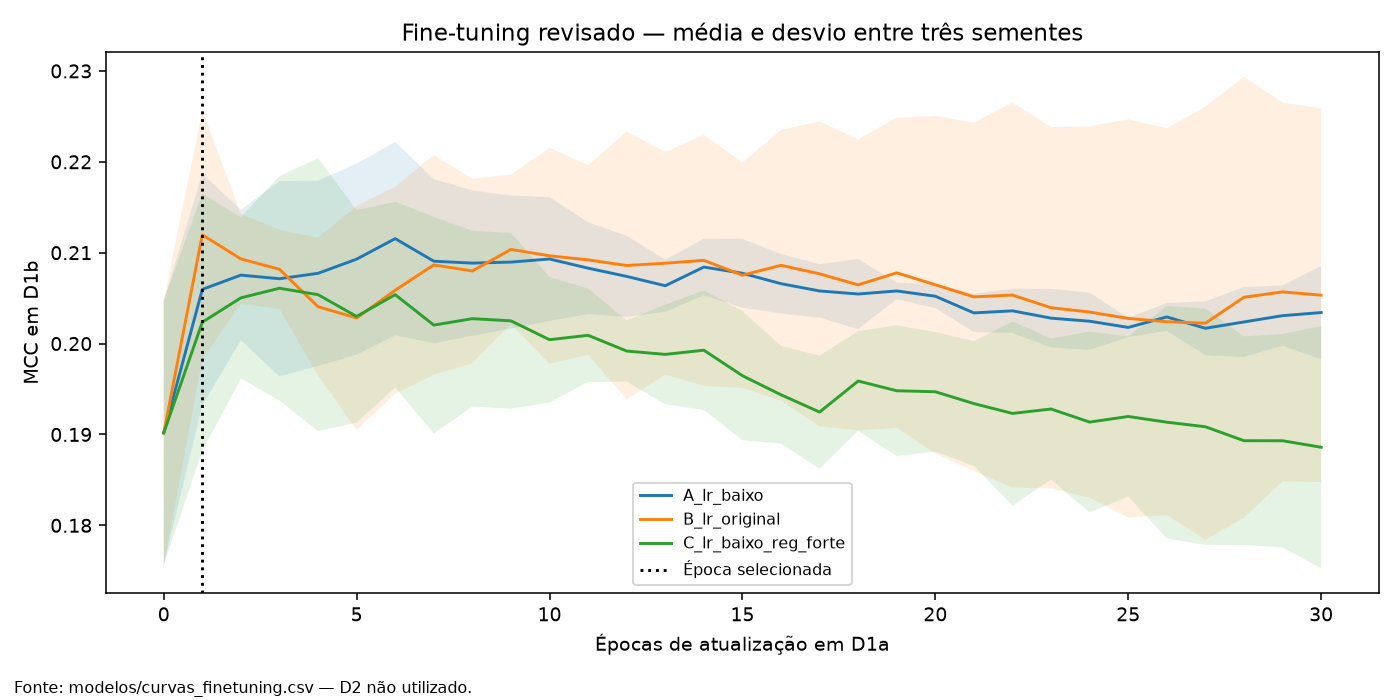

,config,epoca,mean,std
0,A_lr_baixo,0,0.190166,0.014549
1,A_lr_baixo,1,0.205962,0.012730
2,A_lr_baixo,2,0.207533,0.007180
3,A_lr_baixo,3,0.207134,0.010746
4,A_lr_baixo,4,0.207730,0.010187
...,...,...,...,...
88,C_lr_baixo_reg_forte,26,0.191348,0.012789
89,C_lr_baixo_reg_forte,27,0.190848,0.013008
90,C_lr_baixo_reg_forte,28,0.189313,0.011475
91,C_lr_baixo_reg_forte,29,0.189307,0.011737


In [6]:
display(json.loads(Path('modelos/finetuning_escolhido.json').read_text()))
display(Image(filename='resultados/revisao_temporal/finetuning.png'))
curvas = pd.read_csv('modelos/curvas_finetuning.csv')
display(curvas.groupby(['config','epoca']).mcc_d1b.agg(['mean','std']).reset_index())

## Próximo passo

Revisar e congelar o protocolo antes de abrir D2. Os resultados sem embargo foram preservados somente como histórico; não devem ser usados como resultados atuais.